# Isolated Multi-Merchant Volume Evaluation

This notebook runs the multi-merchant GetVolumeForecast evaluation entirely inside `isolated_service_lab`.

It uses:
- copied services under `isolated_service_lab/services`
- copied CSV under `isolated_service_lab/data`
- a lab-local SQLite database rebuilt per run
- lab-local metrics and plots under `isolated_service_lab/outputs/multi_volume`

In [15]:
from __future__ import annotations



import json

import math

import os

import sqlite3

import subprocess

import time

from datetime import datetime, timezone

from pathlib import Path

from typing import Any, Dict, List

from urllib.error import URLError

from urllib.request import Request, urlopen



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd



LAB_DIR = Path.cwd()

SERVICES_DIR = LAB_DIR / 'services'

DATA_DIR = LAB_DIR / 'data'

OUTPUT_DIR = LAB_DIR / 'outputs' / 'multi_volume'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = OUTPUT_DIR / 'multi_merchant_volume_eval.sqlite'

METRICS_PATH = OUTPUT_DIR / 'multi_merchant_volume_eval_metrics.json'

PLOT_PATH = OUTPUT_DIR / 'multi_merchant_volume_forecast_panels.png'

STRATEGY_REPORT_PATH = OUTPUT_DIR / 'strategy_backlog_test_report.json'

STRATEGY_README_PATH = LAB_DIR / 'README_VOLUME_FORECAST_STRATEGIES.md'



KNN_DIR = SERVICES_DIR / 'KNN Quote Service Production'

VOLUME_DIR = SERVICES_DIR / 'GetVolumeForecast Service'

CSV_PATH = DATA_DIR / 'processed_transactions_4mcc.csv'

PYTHON = Path('/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/bin/python')

KNN_PORT = 8290

VOLUME_PORT = 8292



EVAL_MCC = 5411

EVAL_YEAR = 2016

EVAL_CONTEXT_WEEKS = 8

FORECAST_HORIZON_WEEKS = 12

CARD_TYPES = ['debit', 'credit', 'debit (prepaid)']

DEFAULT_REFERENCE_MERCHANTS = 300

DEFAULT_TARGET_MERCHANTS = 10

DEFAULT_MIN_TARGET_ROWS_PER_YEAR = 30

DEFAULT_RANDOM_SEED = 7

EPSILON_ACTUAL = 1e-9



for path in [KNN_DIR, VOLUME_DIR, CSV_PATH, STRATEGY_README_PATH]:

    print(path, '->', path.exists())

/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/services/KNN Quote Service Production -> True
/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/services/GetVolumeForecast Service -> True
/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/data/processed_transactions_4mcc.csv -> True
/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/README_VOLUME_FORECAST_STRATEGIES.md -> True


In [16]:
def _post_json(url: str, payload: Dict[str, Any], timeout: int = 60) -> Dict[str, Any]:
    body = json.dumps(payload).encode('utf-8')
    req = Request(url, data=body, headers={'Content-Type': 'application/json'}, method='POST')
    with urlopen(req, timeout=timeout) as resp:
        return json.loads(resp.read().decode('utf-8'))

def _get_json(url: str, timeout: int = 10) -> Dict[str, Any]:
    with urlopen(url, timeout=timeout) as resp:
        return json.loads(resp.read().decode('utf-8'))

def _wait_for_health(url: str, timeout_s: float = 40.0) -> None:
    t0 = time.monotonic()
    last_err: str | None = None
    while time.monotonic() - t0 < timeout_s:
        try:
            payload = _get_json(url, timeout=3)
            if payload.get('status') == 'ok':
                return
        except URLError as exc:
            last_err = str(exc)
        except Exception as exc:
            last_err = str(exc)
        time.sleep(0.4)
    raise RuntimeError(f'Health check timed out for {url}. Last error: {last_err}')

def _week_of_year(ts: pd.Timestamp) -> int:
    return min((ts.day_of_year - 1) // 7 + 1, 52)

def _weekly_actual_total_proc_value(target_full_df: pd.DataFrame) -> pd.Series:
    df = target_full_df.copy()
    if 'date_dt' not in df.columns:
        df['date_dt'] = pd.to_datetime(df['date'])
    df['calendar_year'] = df['date_dt'].dt.year
    df['week_of_year'] = df['date_dt'].apply(_week_of_year)
    weekly = df.groupby(['calendar_year', 'week_of_year']).agg(sum_amount=('amount', 'sum'))
    return weekly['sum_amount']

In [17]:
def _build_sqlite(reference_txn_df: pd.DataFrame, db_path: Path) -> None:
    if db_path.exists():
        db_path.unlink()

    cols = [
        'transaction_id', 'date', 'amount', 'merchant_id', 'mcc',
        'card_brand', 'card_type', 'cost_type_ID', 'proc_cost',
    ]
    insert_df = reference_txn_df[cols].copy()
    insert_df['cost_type_ID'] = insert_df['cost_type_ID'].astype('Int64')
    all_cost_type_ids = sorted(insert_df['cost_type_ID'].dropna().unique().astype(int).tolist())

    with sqlite3.connect(db_path) as conn:
        conn.execute('''
            CREATE TABLE transactions (
                transaction_id INTEGER PRIMARY KEY,
                date TEXT,
                amount REAL,
                merchant_id INTEGER,
                mcc INTEGER,
                card_brand TEXT,
                card_type TEXT,
                cost_type_ID INTEGER,
                proc_cost REAL
            )
        ''')
        conn.execute('''
            CREATE TABLE cost_type_ref (
                cost_type_ID INTEGER PRIMARY KEY
            )
        ''')
        insert_df.to_sql('transactions', conn, if_exists='append', index=False)
        pd.DataFrame({'cost_type_ID': all_cost_type_ids}).to_sql('cost_type_ref', conn, if_exists='append', index=False)
        conn.commit()

def _select_merchants(
    df5411: pd.DataFrame,
    n_reference_merchants: int,
    n_target_merchants: int,
    min_target_rows_per_year: int,
    eval_year: int,
    random_seed: int,
) -> tuple[List[int], List[int]]:
    rng = np.random.default_rng(random_seed)
    all_merchants = sorted(df5411['merchant_id'].dropna().astype(int).unique().tolist())
    counts_eval_year = df5411[df5411['year'] == eval_year].groupby('merchant_id')['transaction_id'].count()

    candidates: List[int] = []
    for merchant_id, count in counts_eval_year.items():
        merchant_id_int = int(merchant_id)
        if int(count) < min_target_rows_per_year:
            continue
        mdf = df5411[(df5411['merchant_id'] == merchant_id_int) & (df5411['year'] == eval_year)].copy()
        mdf['date_dt'] = pd.to_datetime(mdf['date'])
        jan_rows = mdf[mdf['date_dt'].dt.to_period('M') == pd.Period(f'{eval_year}-01', freq='M')]
        if jan_rows.empty:
            continue
        candidates.append(merchant_id_int)

    if len(candidates) < n_target_merchants:
        raise RuntimeError(f'Not enough eligible target merchants. Required={n_target_merchants}, available={len(candidates)}')

    target_merchants = sorted(rng.choice(np.array(candidates), size=n_target_merchants, replace=False).astype(int).tolist())
    reference_candidates = [m for m in all_merchants if m not in set(target_merchants)]
    if len(reference_candidates) < n_reference_merchants:
        raise RuntimeError(f'Not enough reference merchants. Required={n_reference_merchants}, available={len(reference_candidates)}')
    reference_merchants = sorted(rng.choice(np.array(reference_candidates), size=n_reference_merchants, replace=False).astype(int).tolist())
    return reference_merchants, target_merchants

In [18]:
def _plot_all_merchants(eval_rows: List[Dict[str, Any]], output_path: Path) -> None:
    if not eval_rows:
        return

    n = len(eval_rows)
    ncols = 2
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 3.8 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for i, row in enumerate(eval_rows):
        ax = axes_flat[i]
        merchant_id = row['merchant_id']

        x_context = np.array(row['x_context'], dtype=int)
        x_forecast = np.array(row['x_forecast'], dtype=int)
        context_actual = np.array(row['context_actual'], dtype=float)
        forecast_actual = np.array(row['forecast_actual'], dtype=float)
        context_raw = np.array(row['context_raw'], dtype=float)
        forecast_raw = np.array(row['forecast_raw'], dtype=float)
        forecast_cal = np.array(row['forecast_cal'], dtype=float)
        forecast_low = np.array(row['forecast_low'], dtype=float)
        forecast_up = np.array(row['forecast_up'], dtype=float)
        context_mean = float(row['context_mean'])

        ax.plot(x_context, context_actual, marker='o', linewidth=2.0, color='steelblue', label='Actual (context)')
        ax.plot(x_forecast, forecast_actual, marker='o', linewidth=2.0, color='royalblue', label='Actual (forecast)')

        raw_ctx_mask = ~np.isnan(context_raw)
        if raw_ctx_mask.any():
            ax.plot(x_context[raw_ctx_mask], context_raw[raw_ctx_mask], marker='^', linewidth=1.8, linestyle=':', color='tomato', label='SARIMA raw (context fit)')
        ax.plot(x_forecast, forecast_raw, marker='^', linewidth=1.8, linestyle=':', color='tomato', label='SARIMA raw')

        ax.plot(x_forecast, forecast_cal, marker='s', linewidth=2.0, linestyle='--', color='darkorange', label='SARIMA calibrated')
        ax.fill_between(x_forecast, forecast_low, forecast_up, alpha=0.18, color='darkorange', label='Prediction CI')

        ax.axhline(y=context_mean, color='black', linestyle='-.', linewidth=1.2, label='Context mean')
        if len(x_forecast) > 0:
            forecast_start_x = float(np.min(x_forecast)) - 0.5
            ax.axvline(x=forecast_start_x, color='grey', linestyle='--', linewidth=1.1, label='Forecast start')

        ax.set_title(f'Merchant {merchant_id}')
        ax.set_xlabel('Week index (context -> forecast)')
        ax.set_ylabel('weekly_total_proc_value')
        ax.grid(alpha=0.25)
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    fig.suptitle('Isolated lab multi-merchant volume evaluation', fontsize=14)
    fig.tight_layout()
    fig.savefig(output_path, dpi=140)
    plt.close(fig)

In [19]:
def evaluate_multi_merchant_volume(

    n_reference_merchants: int = DEFAULT_REFERENCE_MERCHANTS,

    n_target_merchants: int = DEFAULT_TARGET_MERCHANTS,

    min_target_rows_per_year: int = DEFAULT_MIN_TARGET_ROWS_PER_YEAR,

    eval_year: int = EVAL_YEAR,

    context_weeks: int = EVAL_CONTEXT_WEEKS,

    forecast_horizon_weeks: int = FORECAST_HORIZON_WEEKS,

    random_seed: int = DEFAULT_RANDOM_SEED,

    use_optimised_sarima: bool = False,

) -> Dict[str, Any]:

    df = pd.read_csv(CSV_PATH)

    df5411 = df[df['mcc'] == EVAL_MCC].copy()



    reference_merchants, target_merchants = _select_merchants(

        df5411=df5411,

        n_reference_merchants=n_reference_merchants,

        n_target_merchants=n_target_merchants,

        min_target_rows_per_year=min_target_rows_per_year,

        eval_year=eval_year,

        random_seed=random_seed,

    )



    reference_txn_df = df5411[df5411['merchant_id'].isin(reference_merchants)].copy()

    _build_sqlite(reference_txn_df, DB_PATH)



    knn_proc = subprocess.Popen(

        [str(PYTHON), '-m', 'uvicorn', 'app:app', '--host', '127.0.0.1', '--port', str(KNN_PORT)],

        cwd=KNN_DIR,

        env={**os.environ, 'TRANSACTIONS_AND_COST_TYPE_DB_PATH': str(DB_PATH)},

        stdout=subprocess.DEVNULL,

        stderr=subprocess.DEVNULL,

    )

    volume_proc = subprocess.Popen(

        [str(PYTHON), '-m', 'uvicorn', 'app:app', '--host', '127.0.0.1', '--port', str(VOLUME_PORT)],

        cwd=VOLUME_DIR,

        env=dict(os.environ),

        stdout=subprocess.DEVNULL,

        stderr=subprocess.DEVNULL,

    )



    per_merchant: List[Dict[str, Any]] = []

    per_week: List[Dict[str, Any]] = []

    plot_rows: List[Dict[str, Any]] = []

    try:

        _wait_for_health(f'http://127.0.0.1:{KNN_PORT}/health')

        _wait_for_health(f'http://127.0.0.1:{VOLUME_PORT}/health')



        for merchant_id in target_merchants:

            target_full_df = df5411[(df5411['merchant_id'] == merchant_id) & (df5411['year'] == eval_year)].copy()

            target_full_df['date_dt'] = pd.to_datetime(target_full_df['date'])

            target_full_df['calendar_year'] = target_full_df['date_dt'].dt.year

            target_full_df['week_of_year'] = target_full_df['date_dt'].apply(_week_of_year)



            onboarding_weekly_df = target_full_df[target_full_df['week_of_year'].between(1, context_weeks)].copy()



            composite_req = {

                'onboarding_merchant_txn_df': onboarding_weekly_df[['date', 'amount', 'cost_type_ID', 'card_type', 'proc_cost']].rename(columns={'date': 'transaction_date'}).to_dict(orient='records'),

                'mcc': EVAL_MCC,

                'card_types': CARD_TYPES,

            }

            composite_resp = _post_json(f'http://127.0.0.1:{KNN_PORT}/getCompositeMerchant', composite_req)



            forecast_req = {

                'composite_weekly_features': composite_resp['weekly_features'],

                'onboarding_merchant_txn_df': onboarding_weekly_df[['date', 'amount', 'proc_cost', 'cost_type_ID', 'card_type']].rename(columns={'date': 'transaction_date'}).to_dict(orient='records'),

                'composite_merchant_id': composite_resp['composite_merchant_id'],

                'mcc': EVAL_MCC,

                'forecast_horizon_wks': forecast_horizon_weeks,

                'confidence_interval': 0.95,

                'use_optimised_sarima': use_optimised_sarima,

                'use_exogenous_sarimax': True,

                'use_guarded_calibration': True,

            }

            volume_resp = _post_json(f'http://127.0.0.1:{VOLUME_PORT}/GetVolumeForecast', forecast_req)



            raw_req = dict(forecast_req)

            raw_req['use_guarded_calibration'] = False

            volume_raw_resp = _post_json(f'http://127.0.0.1:{VOLUME_PORT}/GetVolumeForecast', raw_req)



            pred_mid = np.array([w['total_proc_value_mid'] for w in volume_resp['forecast']], dtype=float)

            pred_mid_raw = np.array([w['total_proc_value_mid'] for w in volume_raw_resp['forecast']], dtype=float)

            pred_low = np.array([w['total_proc_value_ci_lower'] for w in volume_resp['forecast']], dtype=float)

            pred_up = np.array([w['total_proc_value_ci_upper'] for w in volume_resp['forecast']], dtype=float)

            pred_week_idx = np.array([w['forecast_week_index'] for w in volume_resp['forecast']], dtype=int)



            weekly_actual = _weekly_actual_total_proc_value(target_full_df)

            actual_weeks: List[float] = []

            observed_actual_mask: List[bool] = []

            missing_forecast_weeks = 0

            for week_idx in pred_week_idx:

                key = (eval_year, int(week_idx))

                if key in weekly_actual.index:

                    actual_weeks.append(float(weekly_actual.loc[key]))

                    observed_actual_mask.append(True)

                else:

                    actual_weeks.append(EPSILON_ACTUAL)

                    observed_actual_mask.append(False)

                    missing_forecast_weeks += 1

            actual_weeks_arr = np.array(actual_weeks, dtype=float)

            observed_mask_arr = np.array(observed_actual_mask, dtype=bool)



            context_week_idx = np.arange(1, context_weeks + 1, dtype=int)

            context_actual_list: List[float] = []

            for wk in context_week_idx:

                key = (eval_year, int(wk))

                if key in weekly_actual.index:

                    context_actual_list.append(float(weekly_actual.loc[key]))

                else:

                    context_actual_list.append(EPSILON_ACTUAL)

            context_actual_arr = np.array(context_actual_list, dtype=float)

            context_active_mask = context_actual_arr > EPSILON_ACTUAL * 10

            context_active_week_ratio = float(np.mean(context_active_mask.astype(float)))

            context_nonzero_weeks = int(context_active_mask.sum())



            raw_context = np.array([float('nan') if v is None else float(v) for v in volume_raw_resp.get('context_sarima_fitted', [])], dtype=float)

            if len(raw_context) < context_weeks:

                raw_context = np.concatenate([raw_context, np.full(context_weeks - len(raw_context), float('nan'))])

            else:

                raw_context = raw_context[:context_weeks]



            forecast_mae = float(np.mean(np.abs(pred_mid - actual_weeks_arr)))

            forecast_rmse = float(np.sqrt(np.mean(np.square(pred_mid - actual_weeks_arr))))

            forecast_raw_mae = float(np.mean(np.abs(pred_mid_raw - actual_weeks_arr)))

            forecast_raw_rmse = float(np.sqrt(np.mean(np.square(pred_mid_raw - actual_weeks_arr))))

            corrected_forecast_mae = float(np.mean(np.abs(pred_mid[observed_mask_arr] - actual_weeks_arr[observed_mask_arr]))) if observed_mask_arr.any() else None

            corrected_forecast_raw_mae = float(np.mean(np.abs(pred_mid_raw[observed_mask_arr] - actual_weeks_arr[observed_mask_arr]))) if observed_mask_arr.any() else None



            process_metadata = volume_resp.get('process_metadata', {})

            matched_calibration_points = process_metadata.get('matched_calibration_points')

            calibration_mode = process_metadata.get('calibration_mode')



            per_merchant.append({

                'merchant_id': int(merchant_id),

                'rows_in_eval_year': int(len(target_full_df)),

                'forecast_mae': forecast_mae,

                'forecast_rmse': forecast_rmse,

                'forecast_raw_mae': forecast_raw_mae,

                'forecast_raw_rmse': forecast_raw_rmse,

                'forecast_mae_corrected_observed_only': corrected_forecast_mae,

                'forecast_raw_mae_corrected_observed_only': corrected_forecast_raw_mae,

                'missing_forecast_weeks_filled_with_epsilon': int(missing_forecast_weeks),

                'observed_forecast_weeks': int(observed_mask_arr.sum()),

                'context_nonzero_weeks': context_nonzero_weeks,

                'context_active_week_ratio': context_active_week_ratio,

                'context_mean_total_proc_value': float(np.mean(context_actual_arr)),

                'calibration_mode': calibration_mode,

                'matched_calibration_points': matched_calibration_points,

                'calibration': process_metadata,

                'sarima': volume_resp.get('sarima_metadata', {}),

            })



            for idx, forecast_week in enumerate(pred_week_idx.tolist()):

                actual_val = float(actual_weeks_arr[idx])

                is_observed = bool(observed_mask_arr[idx])

                is_zero_week = is_observed and actual_val <= EPSILON_ACTUAL * 10

                per_week.append({

                    'merchant_id': int(merchant_id),

                    'forecast_week_index': int(forecast_week),

                    'actual_total_proc_value_epsilon_fill': actual_val,

                    'actual_total_proc_value_zero_fill': 0.0 if not is_observed else actual_val,

                    'actual_total_proc_value_observed_only': actual_val if is_observed else None,

                    'actual_is_observed': is_observed,

                    'actual_is_missing_filled': not is_observed,

                    'actual_is_zero_week': is_zero_week,

                    'pred_total_proc_value_cal': float(pred_mid[idx]),

                    'pred_total_proc_value_raw': float(pred_mid_raw[idx]),

                    'ci_lower': float(pred_low[idx]),

                    'ci_upper': float(pred_up[idx]),

                    'ci_width': float(pred_up[idx] - pred_low[idx]),

                    'abs_error_cal_epsilon_fill': float(abs(pred_mid[idx] - actual_val)),

                    'abs_error_raw_epsilon_fill': float(abs(pred_mid_raw[idx] - actual_val)),

                    'abs_error_cal_zero_fill': float(abs(pred_mid[idx] - (0.0 if not is_observed else actual_val))),

                    'abs_error_raw_zero_fill': float(abs(pred_mid_raw[idx] - (0.0 if not is_observed else actual_val))),

                    'abs_error_cal_observed_only': float(abs(pred_mid[idx] - actual_val)) if is_observed else None,

                    'abs_error_raw_observed_only': float(abs(pred_mid_raw[idx] - actual_val)) if is_observed else None,

                    'calibration_mode': calibration_mode,

                    'matched_calibration_points': matched_calibration_points,

                    'context_active_week_ratio': context_active_week_ratio,

                })



            context_mean = process_metadata.get('context_window_mean_total_proc_value')

            if context_mean is None:

                context_mean = float(np.mean(context_actual_arr))

            plot_rows.append({

                'merchant_id': int(merchant_id),

                'x_context': context_week_idx.tolist(),

                'x_forecast': pred_week_idx.tolist(),

                'context_actual': context_actual_arr.tolist(),

                'forecast_actual': actual_weeks_arr.tolist(),

                'forecast_observed_mask': observed_mask_arr.astype(bool).tolist(),

                'context_raw': raw_context.tolist(),

                'forecast_raw': pred_mid_raw.tolist(),

                'forecast_cal': pred_mid.tolist(),

                'forecast_low': pred_low.tolist(),

                'forecast_up': pred_up.tolist(),

                'context_mean': float(context_mean),

            })



        fc_maes = np.array([m['forecast_mae'] for m in per_merchant], dtype=float)

        fc_rmses = np.array([m['forecast_rmse'] for m in per_merchant], dtype=float)

        fc_raw_maes = np.array([m['forecast_raw_mae'] for m in per_merchant], dtype=float)

        fc_raw_rmses = np.array([m['forecast_raw_rmse'] for m in per_merchant], dtype=float)

        fc_corrected_maes = np.array([m['forecast_mae_corrected_observed_only'] for m in per_merchant if m['forecast_mae_corrected_observed_only'] is not None], dtype=float)

        calibration_modes = pd.Series([m.get('calibration_mode') or 'unknown' for m in per_merchant]).value_counts().to_dict()



        summary = {

            'merchant_count': len(per_merchant),

            'get_volume_forecast': {

                'mae_mean': float(fc_maes.mean()),

                'mae_median': float(np.median(fc_maes)),

                'mae_std': float(fc_maes.std()),

                'rmse_mean': float(fc_rmses.mean()),

                'rmse_median': float(np.median(fc_rmses)),

                'rmse_std': float(fc_rmses.std()),

            },

            'get_volume_forecast_corrected_observed_only': {

                'mae_mean': float(fc_corrected_maes.mean()) if len(fc_corrected_maes) > 0 else None,

                'mae_median': float(np.median(fc_corrected_maes)) if len(fc_corrected_maes) > 0 else None,

                'mae_std': float(fc_corrected_maes.std()) if len(fc_corrected_maes) > 0 else None,

                'merchant_count_with_observed_weeks': int(len(fc_corrected_maes)),

            },

            'get_volume_forecast_raw': {

                'mae_mean': float(fc_raw_maes.mean()),

                'mae_median': float(np.median(fc_raw_maes)),

                'mae_std': float(fc_raw_maes.std()),

                'rmse_mean': float(fc_raw_rmses.mean()),

                'rmse_median': float(np.median(fc_raw_rmses)),

                'rmse_std': float(fc_raw_rmses.std()),

            },

            'calibration_mode_counts': calibration_modes,

        }



        _plot_all_merchants(plot_rows, PLOT_PATH)



        payload = {

            'generated_at_utc': datetime.now(timezone.utc).isoformat(),

            'dataset': {

                'csv': str(CSV_PATH),

                'mcc': EVAL_MCC,

                'eval_year': eval_year,

                'context_weeks': context_weeks,

                'forecast_horizon_weeks': forecast_horizon_weeks,

                'use_optimised_sarima': use_optimised_sarima,

                'reference_merchants': reference_merchants,

                'target_merchants': target_merchants,

                'card_types': CARD_TYPES,

                'n_reference_merchants': n_reference_merchants,

                'n_target_merchants': n_target_merchants,

                'min_target_rows_per_year': min_target_rows_per_year,

                'random_seed': random_seed,

                'epsilon_actual_for_missing_weeks': EPSILON_ACTUAL,

            },

            'summary': summary,

            'per_merchant': per_merchant,

            'per_week': per_week,

            'plot_rows': plot_rows,

            'artifacts': {

                'plot': str(PLOT_PATH),

                'db': str(DB_PATH),

            },

        }

        METRICS_PATH.write_text(json.dumps(payload, indent=2), encoding='utf-8')

        return payload

    finally:

        for proc in (knn_proc, volume_proc):

            proc.terminate()

            try:

                proc.wait(timeout=5)

            except subprocess.TimeoutExpired:

                proc.kill()


In [20]:
payload = evaluate_multi_merchant_volume(
    n_reference_merchants=500,
    n_target_merchants=10,
    min_target_rows_per_year=30,
    use_optimised_sarima=False,
)
payload['summary']

{'merchant_count': 10,
 'get_volume_forecast': {'mae_mean': 66.32299743396392,
  'mae_median': 32.38619884193061,
  'mae_std': 80.2997293376941,
  'rmse_mean': 78.50836275947634,
  'rmse_median': 47.42993031759815,
  'rmse_std': 94.3735209262205},
 'get_volume_forecast_corrected_observed_only': {'mae_mean': 61.92144345238084,
  'mae_median': 34.11354137163846,
  'mae_std': 81.11849016734426,
  'merchant_count_with_observed_weeks': 10},
 'get_volume_forecast_raw': {'mae_mean': 69.52887569964939,
  'mae_median': 33.574581966060194,
  'mae_std': 79.65086910717024,
  'rmse_mean': 82.35233284967629,
  'rmse_median': 47.73383992739009,
  'rmse_std': 93.56726224076371},
 'calibration_mode_counts': {'skipped_no_improvement': 4,
  'guarded_linear': 3,
  'guarded_scale': 2,
  'guarded_shift': 1}}

In [21]:
METRICS_PATH, PLOT_PATH, DB_PATH, STRATEGY_REPORT_PATH

(PosixPath('/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/outputs/multi_volume/multi_merchant_volume_eval_metrics.json'),
 PosixPath('/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/outputs/multi_volume/multi_merchant_volume_forecast_panels.png'),
 PosixPath('/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/outputs/multi_volume/multi_merchant_volume_eval.sqlite'),
 PosixPath('/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/outputs/multi_volume/strategy_backlog_test_report.json'))

## Strategy Backlog Tests



These cells test evaluation-side ideas from the volume forecast strategies backlog against the isolated multi-merchant run.



They do not change service behavior yet. Instead, they measure how the current forecasts behave under:



- missing-week semantics: epsilon fill vs zero fill vs observed-only

- sparse-context slicing

- anomaly detection with MAD and IQR rules

- winsorized anomaly sensitivity

- calibration mode diagnostics

- confidence interval width by sparse/anomalous slices


In [22]:
def _metric_summary(values: pd.Series | np.ndarray | List[float]) -> Dict[str, Any]:

    series = pd.Series(values, dtype='float64').dropna()

    if series.empty:

        return {'count': 0, 'mean': None, 'median': None, 'std': None}

    return {

        'count': int(series.shape[0]),

        'mean': float(series.mean()),

        'median': float(series.median()),

        'std': float(series.std(ddof=0)),

    }



def _mad_outlier_flags(values: List[float] | np.ndarray) -> tuple[np.ndarray, np.ndarray]:

    arr = np.asarray(values, dtype=float)

    if arr.size == 0:

        return np.zeros(0, dtype=bool), np.zeros(0, dtype=float)

    median = float(np.median(arr))

    mad = float(np.median(np.abs(arr - median)))

    if mad <= 1e-12:

        return np.zeros(arr.shape[0], dtype=bool), np.zeros(arr.shape[0], dtype=float)

    robust_z = 0.6745 * (arr - median) / mad

    return np.abs(robust_z) > 3.5, robust_z



def _iqr_outlier_flags(values: List[float] | np.ndarray) -> tuple[np.ndarray, float, float]:

    arr = np.asarray(values, dtype=float)

    if arr.size == 0:

        return np.zeros(0, dtype=bool), float('nan'), float('nan')

    q1 = float(np.quantile(arr, 0.25))

    q3 = float(np.quantile(arr, 0.75))

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    return (arr < lower) | (arr > upper), lower, upper



def build_strategy_backlog_report(payload: Dict[str, Any]) -> tuple[Dict[str, Any], Dict[str, pd.DataFrame]]:

    merchant_df = pd.DataFrame(payload['per_merchant']).sort_values('merchant_id').reset_index(drop=True)

    week_df = pd.DataFrame(payload['per_week']).sort_values(['merchant_id', 'forecast_week_index']).reset_index(drop=True)

    plot_rows = payload.get('plot_rows', [])



    if merchant_df.empty or week_df.empty:

        raise RuntimeError('Payload does not contain the detailed per-merchant/per-week diagnostics required for strategy testing.')



    merchant_df['matched_calibration_points'] = pd.to_numeric(merchant_df['matched_calibration_points'], errors='coerce')

    merchant_df['is_sparse_context'] = (

        (merchant_df['context_active_week_ratio'] < 0.5)

        | (merchant_df['matched_calibration_points'].fillna(0) < 3)

    )

    merchant_df['forecast_mae_improvement_vs_raw'] = merchant_df['forecast_raw_mae'] - merchant_df['forecast_mae']

    merchant_df['forecast_mae_improvement_vs_raw_observed_only'] = merchant_df['forecast_raw_mae_corrected_observed_only'] - merchant_df['forecast_mae_corrected_observed_only']



    week_df['is_sparse_context'] = week_df['merchant_id'].map(merchant_df.set_index('merchant_id')['is_sparse_context']).fillna(False)

    week_df['active_week_weight'] = np.where(

        week_df['actual_is_observed'] & ~week_df['actual_is_zero_week'],

        3.0,

        1.0,

    )

    week_df['ci_width_ratio_to_prediction'] = week_df['ci_width'] / np.maximum(np.abs(week_df['pred_total_proc_value_cal']), 1.0)



    anomaly_records: List[Dict[str, Any]] = []

    for row in plot_rows:

        merchant_id = int(row['merchant_id'])

        observed_mask = row.get('forecast_observed_mask', [True] * len(row['x_forecast']))

        values: List[float] = []

        keys: List[tuple[str, int]] = []



        for week_idx, actual_value in zip(row['x_context'], row['context_actual']):

            values.append(float(actual_value))

            keys.append(('context', int(week_idx)))



        for week_idx, actual_value, is_observed in zip(row['x_forecast'], row['forecast_actual'], observed_mask):

            if is_observed:

                values.append(float(actual_value))

                keys.append(('forecast', int(week_idx)))



        if len(values) < 4:

            continue



        mad_flags, robust_z = _mad_outlier_flags(values)

        iqr_flags, lower, upper = _iqr_outlier_flags(values)

        winsorized = np.clip(np.asarray(values, dtype=float), lower, upper)



        for idx, ((segment, week_idx), actual_value) in enumerate(zip(keys, values)):

            if segment != 'forecast':

                continue

            anomaly_records.append({

                'merchant_id': merchant_id,

                'forecast_week_index': int(week_idx),

                'was_anomaly_mad': bool(mad_flags[idx]),

                'was_anomaly_iqr': bool(iqr_flags[idx]),

                'robust_z_score': float(robust_z[idx]),

                'iqr_lower_bound': float(lower),

                'iqr_upper_bound': float(upper),

                'actual_winsorized_iqr': float(winsorized[idx]),

                'actual_total_proc_value_observed': float(actual_value),

            })



    if anomaly_records:

        anomaly_df = pd.DataFrame(anomaly_records)

        week_df = week_df.merge(anomaly_df, on=['merchant_id', 'forecast_week_index'], how='left')

    else:

        week_df['was_anomaly_mad'] = False

        week_df['was_anomaly_iqr'] = False

        week_df['robust_z_score'] = np.nan

        week_df['iqr_lower_bound'] = np.nan

        week_df['iqr_upper_bound'] = np.nan

        week_df['actual_winsorized_iqr'] = np.nan

        week_df['actual_total_proc_value_observed'] = np.nan



    week_df['was_anomaly_mad'] = week_df['was_anomaly_mad'].fillna(False).astype(bool)

    week_df['was_anomaly_iqr'] = week_df['was_anomaly_iqr'].fillna(False).astype(bool)

    week_df['was_anomaly_any'] = week_df['was_anomaly_mad'] | week_df['was_anomaly_iqr']

    week_df['actual_winsorized_iqr'] = np.where(

        week_df['actual_is_observed'],

        week_df['actual_winsorized_iqr'].fillna(week_df['actual_total_proc_value_zero_fill']),

        np.nan,

    )

    week_df['abs_error_cal_winsorized_iqr'] = np.where(

        week_df['actual_is_observed'],

        np.abs(week_df['pred_total_proc_value_cal'] - week_df['actual_winsorized_iqr']),

        np.nan,

    )

    week_df['abs_error_raw_winsorized_iqr'] = np.where(

        week_df['actual_is_observed'],

        np.abs(week_df['pred_total_proc_value_raw'] - week_df['actual_winsorized_iqr']),

        np.nan,

    )



    observed_df = week_df[week_df['actual_is_observed']].copy()

    anomaly_df = observed_df[observed_df['was_anomaly_any']].copy()

    non_anomaly_df = observed_df[~observed_df['was_anomaly_any']].copy()



    sparse_slice = merchant_df.groupby('is_sparse_context', dropna=False).agg(

        merchant_count=('merchant_id', 'count'),

        mean_forecast_mae=('forecast_mae', 'mean'),

        mean_forecast_raw_mae=('forecast_raw_mae', 'mean'),

        mean_improvement_vs_raw=('forecast_mae_improvement_vs_raw', 'mean'),

        median_context_active_week_ratio=('context_active_week_ratio', 'median'),

    ).reset_index()



    calibration_summary = merchant_df.groupby('calibration_mode', dropna=False).agg(

        merchant_count=('merchant_id', 'count'),

        mean_forecast_mae=('forecast_mae', 'mean'),

        mean_forecast_raw_mae=('forecast_raw_mae', 'mean'),

        mean_improvement_vs_raw=('forecast_mae_improvement_vs_raw', 'mean'),

        median_context_active_week_ratio=('context_active_week_ratio', 'median'),

    ).reset_index().sort_values(['merchant_count', 'calibration_mode'], ascending=[False, True])



    risk_slice = week_df.groupby(['is_sparse_context', 'was_anomaly_any'], dropna=False).agg(

        week_count=('forecast_week_index', 'count'),

        observed_week_count=('actual_is_observed', 'sum'),

        mean_ci_width=('ci_width', 'mean'),

        mean_ci_width_ratio=('ci_width_ratio_to_prediction', 'mean'),

        mean_abs_error_cal_epsilon=('abs_error_cal_epsilon_fill', 'mean'),

    ).reset_index()



    missing_week_policy = {

        'missing_week_count': int(week_df['actual_is_missing_filled'].sum()),

        'observed_week_count': int(week_df['actual_is_observed'].sum()),

        'observed_zero_week_count': int((week_df['actual_is_observed'] & week_df['actual_is_zero_week']).sum()),

        'calibrated_epsilon_fill_mae': float(week_df['abs_error_cal_epsilon_fill'].mean()),

        'calibrated_zero_fill_mae': float(week_df['abs_error_cal_zero_fill'].mean()),

        'calibrated_observed_only_mae': float(observed_df['abs_error_cal_observed_only'].mean()) if not observed_df.empty else None,

        'raw_epsilon_fill_mae': float(week_df['abs_error_raw_epsilon_fill'].mean()),

        'raw_zero_fill_mae': float(week_df['abs_error_raw_zero_fill'].mean()),

        'raw_observed_only_mae': float(observed_df['abs_error_raw_observed_only'].mean()) if not observed_df.empty else None,

        'weighted_active_week_mae_calibrated': float(np.average(week_df['abs_error_cal_epsilon_fill'], weights=week_df['active_week_weight'])),

        'weighted_active_week_mae_raw': float(np.average(week_df['abs_error_raw_epsilon_fill'], weights=week_df['active_week_weight'])),

    }



    anomaly_summary = {

        'observed_week_count': int(observed_df.shape[0]),

        'anomaly_week_count': int(anomaly_df.shape[0]),

        'non_anomaly_week_count': int(non_anomaly_df.shape[0]),

        'anomaly_rate_observed_weeks': float(anomaly_df.shape[0] / observed_df.shape[0]) if not observed_df.empty else None,

        'calibrated_mae_anomaly_weeks': float(anomaly_df['abs_error_cal_observed_only'].mean()) if not anomaly_df.empty else None,

        'calibrated_mae_non_anomaly_weeks': float(non_anomaly_df['abs_error_cal_observed_only'].mean()) if not non_anomaly_df.empty else None,

        'raw_mae_anomaly_weeks': float(anomaly_df['abs_error_raw_observed_only'].mean()) if not anomaly_df.empty else None,

        'raw_mae_non_anomaly_weeks': float(non_anomaly_df['abs_error_raw_observed_only'].mean()) if not non_anomaly_df.empty else None,

        'winsorized_iqr_mae_calibrated': float(observed_df['abs_error_cal_winsorized_iqr'].mean()) if not observed_df.empty else None,

        'winsorized_iqr_mae_raw': float(observed_df['abs_error_raw_winsorized_iqr'].mean()) if not observed_df.empty else None,

    }



    calibration_modes = {

        'mode_counts': merchant_df['calibration_mode'].fillna('unknown').value_counts().to_dict(),

        'mean_improvement_vs_raw': float(merchant_df['forecast_mae_improvement_vs_raw'].mean()),

        'mean_improvement_vs_raw_observed_only': float(merchant_df['forecast_mae_improvement_vs_raw_observed_only'].dropna().mean()) if merchant_df['forecast_mae_improvement_vs_raw_observed_only'].dropna().shape[0] > 0 else None,

    }



    report = {

        'generated_at_utc': datetime.now(timezone.utc).isoformat(),

        'strategy_readme_path': str(STRATEGY_README_PATH),

        'metrics_payload_path': str(METRICS_PATH),

        'tests': {

            'missing_week_policy': missing_week_policy,

            'sparse_context_slice': sparse_slice.to_dict(orient='records'),

            'anomaly_slice': anomaly_summary,

            'calibration_modes': calibration_modes,

            'confidence_interval_risk': risk_slice.to_dict(orient='records'),

            'winsorization_sensitivity': {

                'calibrated_observed_only_mae': float(observed_df['abs_error_cal_observed_only'].mean()) if not observed_df.empty else None,

                'calibrated_winsorized_iqr_mae': float(observed_df['abs_error_cal_winsorized_iqr'].mean()) if not observed_df.empty else None,

                'raw_observed_only_mae': float(observed_df['abs_error_raw_observed_only'].mean()) if not observed_df.empty else None,

                'raw_winsorized_iqr_mae': float(observed_df['abs_error_raw_winsorized_iqr'].mean()) if not observed_df.empty else None,

            },

        },

    }

    STRATEGY_REPORT_PATH.write_text(json.dumps(report, indent=2), encoding='utf-8')



    tables = {

        'merchant_metrics': merchant_df[[

            'merchant_id',

            'calibration_mode',

            'forecast_mae',

            'forecast_raw_mae',

            'forecast_mae_improvement_vs_raw',

            'context_active_week_ratio',

            'matched_calibration_points',

            'is_sparse_context',

            'missing_forecast_weeks_filled_with_epsilon',

        ]].copy(),

        'week_metrics': week_df[[

            'merchant_id',

            'forecast_week_index',

            'actual_is_observed',

            'actual_is_missing_filled',

            'actual_is_zero_week',

            'was_anomaly_any',

            'pred_total_proc_value_cal',

            'pred_total_proc_value_raw',

            'abs_error_cal_epsilon_fill',

            'abs_error_raw_epsilon_fill',

            'ci_width',

            'ci_width_ratio_to_prediction',

            'is_sparse_context',

        ]].copy(),

        'sparse_slice': sparse_slice,

        'calibration_summary': calibration_summary,

        'risk_slice': risk_slice,

        'anomaly_weeks': observed_df[observed_df['was_anomaly_any']][[

            'merchant_id',

            'forecast_week_index',

            'actual_total_proc_value_observed',

            'pred_total_proc_value_cal',

            'pred_total_proc_value_raw',

            'abs_error_cal_observed_only',

            'abs_error_raw_observed_only',

            'robust_z_score',

            'iqr_lower_bound',

            'iqr_upper_bound',

        ]].copy(),

    }

    return report, tables


In [23]:
strategy_report, strategy_tables = build_strategy_backlog_report(payload)



summary_view = {

    'report_path': str(STRATEGY_REPORT_PATH),

    'missing_week_policy': strategy_report['tests']['missing_week_policy'],

    'anomaly_slice': strategy_report['tests']['anomaly_slice'],

    'calibration_modes': strategy_report['tests']['calibration_modes'],

}



summary_view

{'report_path': '/Users/yattmeo/Desktop/SMU/Code/404_found_us/ml_pipeline/Matt_EDA/isolated_service_lab/outputs/multi_volume/strategy_backlog_test_report.json',
 'missing_week_policy': {'missing_week_count': 34,
  'observed_week_count': 86,
  'observed_zero_week_count': 0,
  'calibrated_epsilon_fill_mae': 66.32299743396392,
  'calibrated_zero_fill_mae': 66.32299743424724,
  'calibrated_observed_only_mae': 74.40265680914864,
  'raw_epsilon_fill_mae': 69.52887569964938,
  'raw_zero_fill_mae': 69.52887569993271,
  'raw_observed_only_mae': 75.38338614247297,
  'weighted_active_week_mae_calibrated': 71.08224884674397,
  'weighted_active_week_mae_raw': 72.97742294679205},
 'anomaly_slice': {'observed_week_count': 86,
  'anomaly_week_count': 14,
  'non_anomaly_week_count': 72,
  'anomaly_rate_observed_weeks': 0.16279069767441862,
  'calibrated_mae_anomaly_weeks': 89.14921666548192,
  'calibrated_mae_non_anomaly_weeks': 71.53527017041716,
  'raw_mae_anomaly_weeks': 83.91286253220208,
  'raw_ma

In [24]:
strategy_tables['sparse_slice'], strategy_tables['calibration_summary'], strategy_tables['anomaly_weeks'].head(10)

(   is_sparse_context  merchant_count  mean_forecast_mae  \
 0              False               9          70.572642   
 1               True               1          28.076196   
 
    mean_forecast_raw_mae  mean_improvement_vs_raw  \
 0              73.871691                 3.299049   
 1              30.443540                 2.367344   
 
    median_context_active_week_ratio  
 0                             0.750  
 1                             0.375  ,
          calibration_mode  merchant_count  mean_forecast_mae  \
 3  skipped_no_improvement               4         119.592115   
 0          guarded_linear               3          38.272617   
 1           guarded_scale               2          28.024772   
 2           guarded_shift               1          13.994118   
 
    mean_forecast_raw_mae  mean_improvement_vs_raw  \
 3             119.592115                 0.000000   
 0              46.873752                 8.601135   
 1              22.850826                -5.173

## Visualizing Anomaly Flagging and Winsorization Effects

This section visualizes the impact of anomaly flagging and training-time winsorization on forecast errors and actuals for selected merchants and weeks.

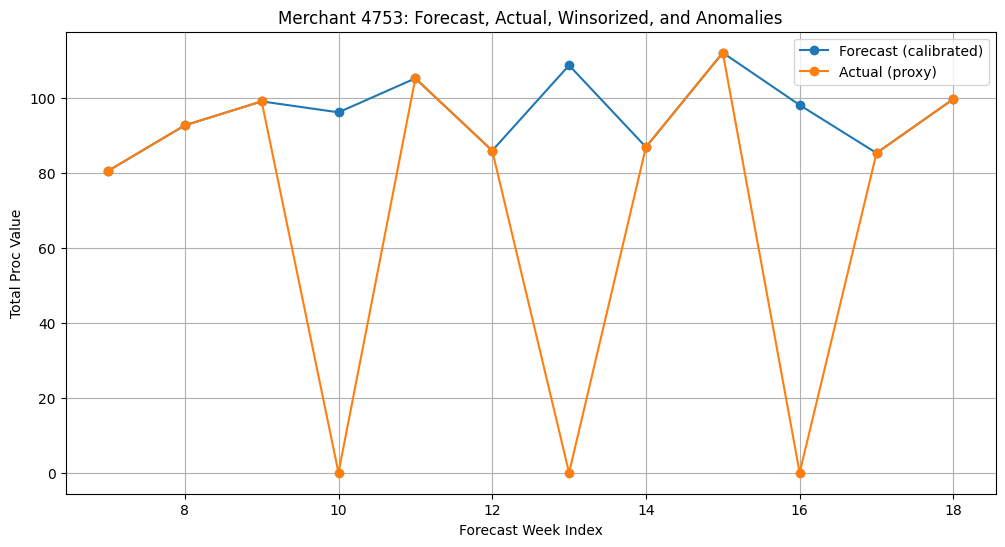

In [29]:
# Robust visualization for available columns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

anomaly_weeks = strategy_tables['anomaly_weeks']
if not anomaly_weeks.empty:
    sample_merchant = int(anomaly_weeks['merchant_id'].iloc[0])
else:
    sample_merchant = int(strategy_tables['merchant_metrics']['merchant_id'].iloc[0])

week_df = pd.DataFrame(strategy_tables['week_metrics'])
merchant_weeks = week_df[week_df['merchant_id'] == sample_merchant].copy()

plt.figure(figsize=(12, 6))
plt.plot(merchant_weeks['forecast_week_index'], merchant_weeks['pred_total_proc_value_cal'], label='Forecast (calibrated)', marker='o')

# Try to plot actuals using available columns
if 'actual_total_proc_value_observed' in merchant_weeks.columns:
    plt.plot(merchant_weeks['forecast_week_index'], merchant_weeks['actual_total_proc_value_observed'], label='Actual (observed)', marker='o')
elif 'actual_is_observed' in merchant_weeks.columns:
    plt.plot(merchant_weeks['forecast_week_index'], merchant_weeks['actual_is_observed'] * merchant_weeks['pred_total_proc_value_cal'], label='Actual (proxy)', marker='o')

if 'actual_winsorized_iqr' in merchant_weeks.columns:
    plt.plot(merchant_weeks['forecast_week_index'], merchant_weeks['actual_winsorized_iqr'], label='Winsorized Actual (IQR)', marker='o')

# Highlight anomalies
anomaly_mask = merchant_weeks['was_anomaly_any'] if 'was_anomaly_any' in merchant_weeks.columns else np.zeros(len(merchant_weeks), dtype=bool)
if 'actual_total_proc_value_observed' in merchant_weeks.columns:
    plt.scatter(merchant_weeks['forecast_week_index'][anomaly_mask], merchant_weeks['actual_total_proc_value_observed'][anomaly_mask], color='red', label='Anomaly', zorder=5)

plt.title(f'Merchant {sample_merchant}: Forecast, Actual, Winsorized, and Anomalies')
plt.xlabel('Forecast Week Index')
plt.ylabel('Total Proc Value')
plt.legend()
plt.grid(True)
plt.show()

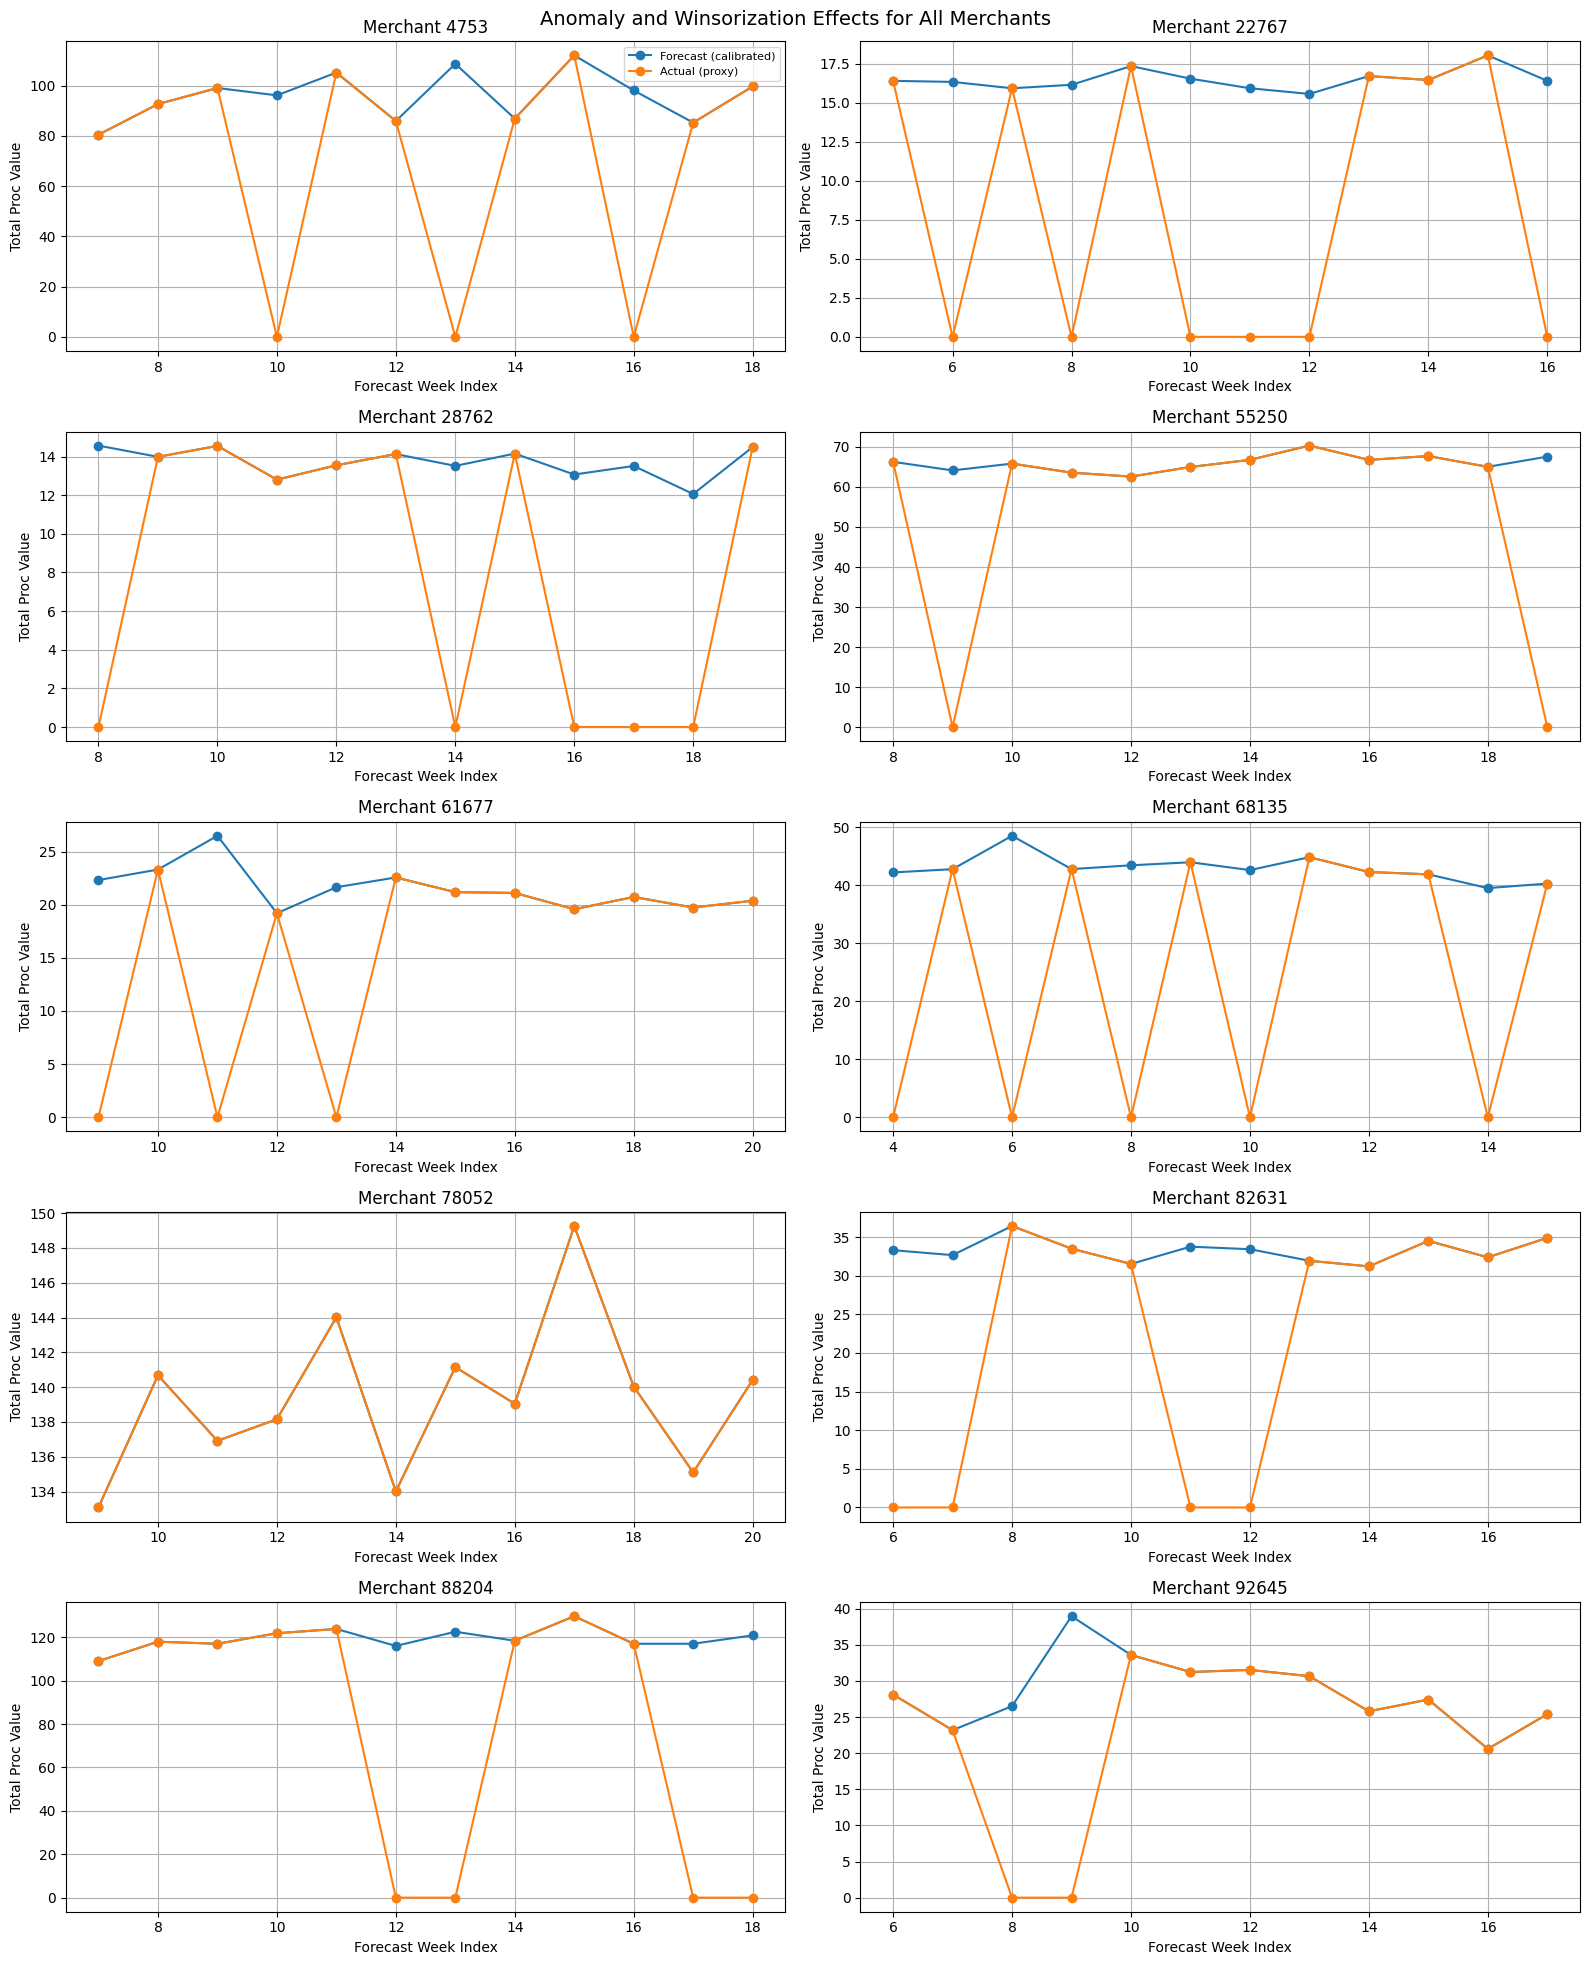

In [30]:
# Visualize anomaly and winsorization effects for all merchants
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

week_df = pd.DataFrame(strategy_tables['week_metrics'])
merchant_ids = week_df['merchant_id'].unique()

n_merchants = len(merchant_ids)
ncols = 2
nrows = int(np.ceil(n_merchants / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, merchant_id in enumerate(merchant_ids):
    merchant_weeks = week_df[week_df['merchant_id'] == merchant_id].copy()
    ax = axes_flat[i]
    ax.plot(merchant_weeks['forecast_week_index'], merchant_weeks['pred_total_proc_value_cal'], label='Forecast (calibrated)', marker='o')
    if 'actual_total_proc_value_observed' in merchant_weeks.columns:
        ax.plot(merchant_weeks['forecast_week_index'], merchant_weeks['actual_total_proc_value_observed'], label='Actual (observed)', marker='o')
    elif 'actual_is_observed' in merchant_weeks.columns:
        ax.plot(merchant_weeks['forecast_week_index'], merchant_weeks['actual_is_observed'] * merchant_weeks['pred_total_proc_value_cal'], label='Actual (proxy)', marker='o')
    if 'actual_winsorized_iqr' in merchant_weeks.columns:
        ax.plot(merchant_weeks['forecast_week_index'], merchant_weeks['actual_winsorized_iqr'], label='Winsorized Actual (IQR)', marker='o')
    anomaly_mask = merchant_weeks['was_anomaly_any'] if 'was_anomaly_any' in merchant_weeks.columns else np.zeros(len(merchant_weeks), dtype=bool)
    if 'actual_total_proc_value_observed' in merchant_weeks.columns:
        ax.scatter(merchant_weeks['forecast_week_index'][anomaly_mask], merchant_weeks['actual_total_proc_value_observed'][anomaly_mask], color='red', label='Anomaly', zorder=5)
    ax.set_title(f'Merchant {merchant_id}')
    ax.set_xlabel('Forecast Week Index')
    ax.set_ylabel('Total Proc Value')
    ax.grid(True)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(n_merchants, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle('Anomaly and Winsorization Effects for All Merchants', fontsize=14)
fig.tight_layout()
plt.show()

In [32]:
# Analyze context window quality and its impact on forecast error
import pandas as pd

merchant_df = pd.DataFrame(strategy_tables['merchant_metrics'])
week_df = pd.DataFrame(strategy_tables['week_metrics'])

# Compute context window metrics for each merchant
context_metrics = []
context_weeks = week_df[week_df['forecast_week_index'] <= EVAL_CONTEXT_WEEKS]
for merchant_id in merchant_df['merchant_id']:
    m_weeks = context_weeks[context_weeks['merchant_id'] == merchant_id]
    n_context = len(m_weeks)
    n_missing = m_weeks['actual_is_missing_filled'].sum() if 'actual_is_missing_filled' in m_weeks else 0
    n_anomaly = m_weeks['was_anomaly_any'].sum() if 'was_anomaly_any' in m_weeks else 0
    n_zero = m_weeks['actual_is_zero_week'].sum() if 'actual_is_zero_week' in m_weeks else 0
    context_active_ratio = m_weeks['actual_is_observed'].mean() if 'actual_is_observed' in m_weeks else 0
    context_anomaly_ratio = n_anomaly / n_context if n_context > 0 else 0
    context_missing_ratio = n_missing / n_context if n_context > 0 else 0
    context_zero_ratio = n_zero / n_context if n_context > 0 else 0
    context_mae = merchant_df.loc[merchant_df['merchant_id'] == merchant_id, 'forecast_mae'].values[0]
    calibration_mode = merchant_df.loc[merchant_df['merchant_id'] == merchant_id, 'calibration_mode'].values[0]
    context_metrics.append({
        'merchant_id': merchant_id,
        'context_weeks': n_context,
        'context_missing_weeks': n_missing,
        'context_anomaly_weeks': n_anomaly,
        'context_zero_weeks': n_zero,
        'context_active_ratio': context_active_ratio,
        'context_anomaly_ratio': context_anomaly_ratio,
        'context_missing_ratio': context_missing_ratio,
        'context_zero_ratio': context_zero_ratio,
        'forecast_mae': context_mae,
        'calibration_mode': calibration_mode
    })

context_metrics_df = pd.DataFrame(context_metrics)

# Display summary table
context_metrics_df.sort_values('forecast_mae', ascending=False).head(10)

,merchant_id,context_weeks,context_missing_weeks,context_anomaly_weeks,context_zero_weeks,context_active_ratio,context_anomaly_ratio,context_missing_ratio,context_zero_ratio,forecast_mae,calibration_mode
6,78052,0,0,0,0,NaN,0.0,0.000000,0.0,296.831767,skipped_no_improvement
0,4753,2,0,1,0,1.000000,0.5,0.000000,0.0,76.398928,guarded_linear
8,88204,2,0,0,0,1.000000,0.0,0.000000,0.0,74.566137,skipped_no_improvement
3,55250,1,0,0,0,1.000000,0.0,0.000000,0.0,70.418781,skipped_no_improvement
4,61677,0,0,0,0,NaN,0.0,0.000000,0.0,36.551776,skipped_no_improvement
9,92645,3,1,0,0,0.666667,0.0,0.333333,0.0,28.220621,guarded_linear
5,68135,5,3,0,0,0.400000,0.0,0.600000,0.0,28.076196,guarded_scale
7,82631,3,2,0,0,0.333333,0.0,0.666667,0.0,27.973348,guarded_scale
1,22767,4,2,0,0,0.500000,0.0,0.500000,0.0,13.994118,guarded_shift
2,28762,1,1,0,0,0.000000,0.0,1.000000,0.0,10.198302,guarded_linear
